# BAU projections
In this section, we now take a look at the future trends and estimate future ash generation for the Business-As-Usual Scenario. We do this in three steps: <br>
1) We build a model to obtain future projections of MSW Generation. This model is based on the World Bank model for future generation of MSW. 
2) We build a model to obtain future projections of treatment methods, to understand the role of recycling, incineration and landfilling in the future. 
3) Finally, we combine the two models to obtain future MSW incinerated. This is then multiplied by ash generated per unit waste incinerated to obtain future ash quantities. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize, curve_fit, show_options
from functools import partial


In [2]:
# Load data
eu_msw = pd.read_csv("../data/processed/EU_MSW_Cleaned_Data.csv")
eu_msw = eu_msw[eu_msw['Country']!='EU27_2020']
eu27 = eu_msw.Country.unique()

eu_msw["INC%"] = eu_msw["DSP_I_RCV_E"]/eu_msw["TRT"]
eu_msw["TRT%"] = eu_msw["TRT"]/eu_msw["GEN"]
eu_msw["GEN%"] = eu_msw["GEN"]/eu_msw["GEN"]
eu_msw["DIS%"] = eu_msw["DSP_L_OTH"]/eu_msw["TRT"]
eu_msw["RCY%"] = eu_msw["RCY"]/eu_msw["TRT"]

#Dropping NaN values
eu_msw.dropna(subset=['INC%'], inplace=True)

In [3]:
country_codes = pd.read_csv('../data/processed/Country_Codes.csv')
missing_data = pd.read_csv('../data/processed/Missing_data.csv')
eu_msw_cap = pd.read_csv('../data/processed/EU_MSW_percap_Cleaned.csv')

## MSW Generation Model

First we build the model to project future MSW generation trends. This model is based on the World Bank model that uses GDP and population as the drivers. However, we recalibrate the original model to the data used in this study, in order to obtain better fit. Thus, in this section we recalibrate the World Bank Model and obtain the new parameters of the model.

### Data extraction and processing

We use OECD data for MSW in countries (to include non-EU countries) OECD data for GDP PPP 2015 (to remain consistent) to recalibrate the model.

In [5]:
# Data Extraction and Cleaning
msw_oecd = pd.read_csv('../data/external/msw_oecd.csv') 
oecd_vars = ["REF_AREA","Reference area", "Measure","UNIT_MEASURE","TIME_PERIOD", "OBS_VALUE"]
msw_oecd = msw_oecd[oecd_vars]
msw_cap = msw_oecd.loc[msw_oecd["UNIT_MEASURE"]=='KG_PS']
msw_cap.drop(['Measure','UNIT_MEASURE'], axis = 'columns', inplace = True)
msw_cap.rename(columns={'TIME_PERIOD':'TIME','OBS_VALUE':'MSW/CAP'}, inplace = True)

#Dropping rows with country groups like OECD
cou_groups=['OECDE','OECDA','EU27_2020','OECDSO','OECD']
msw_cap= msw_cap.loc[~msw_cap['REF_AREA'].isin(cou_groups)]

#Getting GDP PPP 2015/cap
gdp_cap=pd.read_csv('../data/external/GDP/OECD_gdp.csv')
gdp_cap=gdp_cap.loc[gdp_cap['VARIABLE']=='GDPVD_CAP']
gdp_cap=gdp_cap.loc[~gdp_cap['LOCATION'].isin(['G20', 'EA17', 'OECD', 'G20ADV', 'G20EME','OECDG20', 'G7M'])]
gdp_cap = gdp_cap[['LOCATION','TIME','Value']]
gdp_cap.rename(columns={'Value':'GDPCAP_USD'}, inplace = True)

/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/1937371596.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  msw_cap.drop(['Measure','UNIT_MEASURE'], axis = 'columns', inplace = True)
/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/1937371596.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  msw_cap.rename(columns={'TIME_PERIOD':'TIME','OBS_VALUE':'MSW/CAP'}, inplace = True)


### Getting parameters of the Model

The model used is: 
$$
\textrm{Proxy MSW GEN/capita} = a + b\ln{(GDP/cap)}+c\ln{(GDP/cap)}^{2}
$$

$$
{\textrm{Projected MSW GEN/cap}_{\textrm{target year}}=\frac{\textrm{Proxy MSW GEN/cap}_{\textrm{target year}}}{\textrm{Proxy MSW GEN/cap}_{\textrm{base year}}}\times\textrm{Actual MSW GEN/cap}_{\textrm{base year}}}
$$


The input data is used to determine the parameters $a$, $b$, and $c$

In [6]:
#Combining the two datasets
msw_gdp_cap = pd.merge(msw_cap, gdp_cap, left_on = ['TIME','REF_AREA'],right_on = ['TIME','LOCATION'], how ='inner')
msw_gdp_cap.drop_duplicates(inplace=True)

In [7]:
#Calibrating the WB formula
fit = np.polyfit(np.log(msw_gdp_cap['GDPCAP_USD']), msw_gdp_cap['MSW/CAP'], 2)
wb_fit = [29.43, -419.73 , 1647.41]

The obtained fit is :[18.52534507, -176.90063059, 318.11762839]

The World Bank model fit was: [29.43, -419.73 , 1647.41]

In [8]:
#Function to estimate the projection from the obtain fit function
from functions import log_fit_fun as fit_fun
from functions import msw_gen_model as projections

### Plotting the projections

The base year for the model is 2019.

/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/3834604180.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['Projections'] = projections(reg_data[['TIME','MSW/CAP']], reg_data[['TIME','GDPCAP_USD']],  2021,fit, 2016, ['TIME', 'GDPCAP_USD','MSW/CAP'])
/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/3834604180.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['WB_Projections'] = projections(reg_data[['TIME','MSW/CAP']], reg_data[['TIME','GDPCAP_USD']]

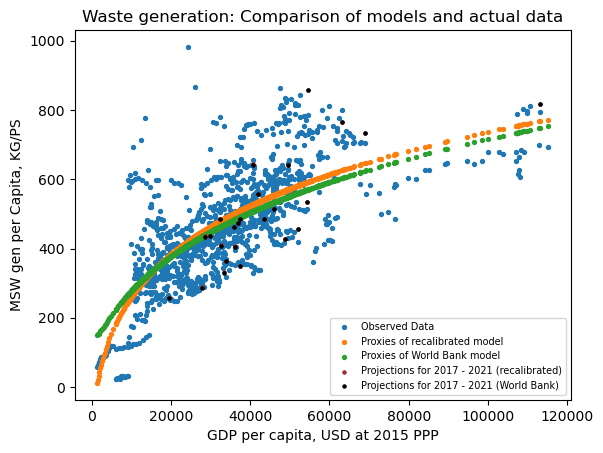

In [9]:
#Plot of projected waste generation

proj_data = pd.DataFrame(columns=['GDPCAP_USD','Projections'])
base_year = 2016

for region in msw_gdp_cap['REF_AREA'].unique():
    reg_data = msw_gdp_cap.loc[msw_gdp_cap['REF_AREA']==region]
    proxy_base = fit_fun(reg_data.loc[reg_data['TIME']==2016]['GDPCAP_USD'],fit).to_numpy()
    if proxy_base.size==0:
        #print(reg_data)
        #print(region)
        continue
    reg_data['Projections'] = projections(reg_data[['TIME','MSW/CAP']], reg_data[['TIME','GDPCAP_USD']],  2021,fit, 2016, ['TIME', 'GDPCAP_USD','MSW/CAP'])
    reg_data['WB_Projections'] = projections(reg_data[['TIME','MSW/CAP']], reg_data[['TIME','GDPCAP_USD']],  2021,wb_fit, 2016, ['TIME', 'GDPCAP_USD','MSW/CAP'])

    reg_data = reg_data.loc[reg_data['TIME'].isin(np.arange(2017,2022))]
    reg_data['Proxies'] = fit_fun(reg_data['GDPCAP_USD'],fit)
    reg_data['WB_Proxies'] = fit_fun(reg_data['GDPCAP_USD'], wb_fit)
    proj_data = pd.concat([proj_data, reg_data[['GDPCAP_USD','Projections','WB_Projections']]])

plt.scatter(msw_gdp_cap['GDPCAP_USD'],msw_gdp_cap['MSW/CAP'],label ='Observed Data', s = 8)
plt.scatter(msw_gdp_cap['GDPCAP_USD'], fit_fun(msw_gdp_cap['GDPCAP_USD'], fit), label = 'Proxies of recalibrated model', s=8)
plt.scatter(msw_gdp_cap['GDPCAP_USD'], fit_fun(msw_gdp_cap['GDPCAP_USD'], wb_fit), label = 'Proxies of World Bank model', s = 8)
plt.scatter(proj_data['GDPCAP_USD'],proj_data['Projections'],  label = 'Projections for 2017 - 2021 (recalibrated)',color = 'brown', s = 5)
plt.scatter(proj_data['GDPCAP_USD'],proj_data['WB_Projections'], label = 'Projections for 2017 - 2021 (World Bank)',color = 'black', s=5)
plt.xlabel('GDP per capita, USD at 2015 PPP')
plt.ylabel('MSW gen per Capita, KG/PS')
plt.title('Waste generation: Comparison of models and actual data')
plt.legend(loc="lower right", prop={'size': 7})
plt.show()

In [10]:
base_year = 2019

## Data gaps in MSW data
Some countries have missing information for the later years which need to be filled in using the BAU model. Here, we use the model to fill in data for the missing countries that were identified earlier.

In [ ]:
gdp_cap = pd.read_csv('../data/processed/eu_gdp_percap_projections_cleaned.csv')
pop= pd.read_csv('../data/processed/eu_population_projections_cleaned.csv')

In [20]:
#Missing Data to be filled in by BAU model

country_check = country_codes["NUTS_code"].iloc[:31]
missing_data_cap = []
for country in country_check:
    for year in np.arange(2010, 2022):
        if eu_msw_cap.loc[(eu_msw_cap["Country"]==country) & (eu_msw_cap["TIME_PERIOD"]==year)].empty:
            missing_data_cap.append([country,year])
            
missing_data_cap = pd.DataFrame(missing_data_cap, columns = ["Country", "TIME_PERIOD"])

In [21]:
#creating a dataframe with all data - msw, msw/cap, gdp/cap, pop, inc, inc%

bau_data = pd.merge(gdp_cap, pop, on = ['LOCATION', 'TIME'] , how = 'outer')

bau_data = pd.merge(bau_data, eu_msw[['Country','TIME_PERIOD','GEN', 'DSP_I_RCV_E', 'INC%']], how = 'left', left_on = ['LOCATION','TIME'], right_on=['Country','TIME_PERIOD'])
bau_data.drop(['Country','TIME_PERIOD'], axis = 1, inplace=True)
bau_data.rename(columns = {'GEN':'MSW_GEN_T', 'DSP_I_RCV_E':'INC_T'}, inplace = True)
bau_data['MSW_GEN_T']*=1e3
bau_data['INC_T']*=1e3

bau_data = pd.merge(bau_data, eu_msw_cap[['Country','TIME_PERIOD','GEN']], how = 'left', left_on = ['LOCATION','TIME'], right_on=['Country','TIME_PERIOD'])
bau_data.drop(['Country','TIME_PERIOD'], axis = 1, inplace=True)
bau_data.rename(columns = {'GEN':'MSW_GEN_CAP_KG/PS',}, inplace = True)

In [24]:
# getting the projections of msw generated for the missing data in years 2020, 2021

for index, row in missing_data_cap.iterrows():
    country = row['Country']
    year = row['TIME_PERIOD']
    
    predict_msw = projections(bau_data[['TIME', 'MSW_GEN_CAP_KG/PS','LOCATION']].loc[(bau_data["LOCATION"]==country)], bau_data[['TIME', 'GDPVD_CAP','LOCATION']].loc[(bau_data["LOCATION"]==country)],  year, fit, 2019,['TIME', 'GDPVD_CAP', 'MSW_GEN_CAP_KG/PS']).to_numpy()
    
    bau_data.loc[(bau_data['LOCATION'] == country) & (bau_data['TIME'] == year), ['MSW_GEN_CAP_KG/PS']] = predict_msw
    bau_data.loc[(bau_data['LOCATION'] == country) & (bau_data['TIME'] == year), ['MSW_GEN_T']] = predict_msw * pop.loc[(pop['LOCATION'] == country) & (pop['TIME'] == year)]['POP'].to_numpy() /1e3

## BAU projections for MSW GEN

After filling in the data gaps, the future projections and obtained and stored in the BAU Dataframe.

In [25]:
for region in bau_data['LOCATION'].unique():
    reg_data = bau_data.loc[bau_data['LOCATION']==region]
    # Get the MSW/CAP data from the model
    bau_data.loc[(bau_data['LOCATION']==region)&(bau_data['TIME'].isin(np.arange(
        2022, 2051))),'MSW_GEN_CAP_KG/PS'] = projections(reg_data[['TIME','MSW_GEN_CAP_KG/PS']],reg_data[[
            'TIME','GDPVD_CAP']], np.arange(2022, 2051), fit, 2019, ['TIME','GDPVD_CAP', 'MSW_GEN_CAP_KG/PS']) 
    #Multiply by population to get total MSW GEN
    bau_data.loc[(bau_data['LOCATION']==region)&(bau_data['TIME'].isin(np.arange(
        2022, 2051))),'MSW_GEN_T'] = bau_data['POP']*bau_data['MSW_GEN_CAP_KG/PS']/1e3

## Treatment Methods Model

The future trends of the treatment methods of MSW are then modelled. We use a constrained logistic time series regression to do this.

### Setting up the Model

The model is given below:

$$
DIS \% (D) = \cfrac{L_1}{1 + e^{-k_1(year-x_{01})}}
$$
$$
RCY\%(R) = \cfrac{L_2}{1 + e^{-k_2(year-x_{02})}}
$$
$$
INC\%(I) = 1 -D- R
$$


Where $DIS$ refers to landfill %, $RCY$ refers to recycling %, and $INC$ refers to incineration % of MSW. 

The above model is constrained on the following conditions:

$$
\{ D + R\le 1\}
$$
$$
\{ L_2\le1\}
$$
$$
\{0\le k_2\}
$$
$$
\{k_1\le 0\}
$$

In [27]:
# S-fit for INC 
from functions import logistic_fun, con_1, con_2, con_3, con_4, objective, model_D_R
from functions import estimate_incineration as I

### Implementation of the model

In [28]:
# Getting INC% for all countries and the corresponding inc quantities

for region in bau_data['LOCATION'].unique():
    reg_data = eu_msw.loc[eu_msw['Country']==region]
    
    #For GRC it is from 2020, IRL from 20221 and others from 2022
    #to calibrate this model, we are using data from all years
    years = np.arange(reg_data.iloc[0]["TIME_PERIOD"], 2051)
    
    initial_params = [reg_data.iloc[0]["DIS%"], -1, reg_data.iloc[0]["TIME_PERIOD"], reg_data.iloc[0]["RCY%"], 1, reg_data.iloc[0]["TIME_PERIOD"]]
    bounds = [(-np.inf, np.inf), (-np.inf, 0), (-np.inf, np.inf),(-np.inf, 1),(0, np.inf),(-np.inf, np.inf)]
    
    cons = [{'type': 'ineq', 'fun': partial(con_4, years=years)}
            ]
    
    years = reg_data["TIME_PERIOD"].to_numpy()
    results = minimize(objective, initial_params, args=(years, reg_data["INC%"].to_numpy(),reg_data["DIS%"].to_numpy(),reg_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, options ={ 'maxfev': 10000})
    
    # Extract the fitted parameters
    params = results.x
    
    if region == 'GRC':
        start_year = 2020
    elif region == 'IRL':
        start_year = 2021
    else:
        start_year = 2022
    
    bau_data.loc[(bau_data['LOCATION']==region)&(bau_data['TIME'].isin(np.arange(
        start_year, 2051))),'INC%'] = I(params, np.arange(start_year, 2051))
    
    bau_data.loc[(bau_data['LOCATION']==region)&(bau_data['TIME'].isin(np.arange(
        start_year, 2051))),'DIS%'] = model_D_R(params[0:3], np.arange(start_year, 2051))
    
    bau_data.loc[(bau_data['LOCATION']==region)&(bau_data['TIME'].isin(np.arange(
        start_year, 2051))),'RCY%'] = model_D_R(params[3:], np.arange(start_year, 2051))
    
    bau_data.loc[(bau_data['LOCATION']==region)&(bau_data['TIME'].isin(np.arange(
        start_year, 2051))),'INC_T'] = bau_data["INC%"]*bau_data['MSW_GEN_T']
            

/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/3922348716.py:17: OptimizeWarning: Unknown solver options: maxfev
  results = minimize(objective, initial_params, args=(years, reg_data["INC%"].to_numpy(),reg_data["DIS%"].to_numpy(),reg_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, options ={ 'maxfev': 10000})
/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/3922348716.py:17: OptimizeWarning: Unknown solver options: maxfev
  results = minimize(objective, initial_params, args=(years, reg_data["INC%"].to_numpy(),reg_data["DIS%"].to_numpy(),reg_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, options ={ 'maxfev': 10000})
/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/3922348716.py:17: OptimizeWarning: Unknown solver options: maxfev
  results = minimize(objective, initial_params, args=(years, reg_data["INC%"].to_numpy(),reg_data["DIS%"].to_numpy(),reg_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, opt

### Plotting the results

In [ ]:
fig, axs = plt.subplots(8, 4, figsize=(20, 35))
axs=axs.flatten()
legend_handles = []
legend_labels = ['Historic Landfill%','Landfill% Trend', 'Historic Recycling%', 'Recycling% Trend', 'Historic Incineration%','Incineration% Trend']

i=0
for region in eu27:
    reg_data = eu_msw.loc[eu_msw['Country']==region]
    years = np.arange(reg_data.iloc[0]["TIME_PERIOD"], 2051)
    
    initial_params = [reg_data.iloc[0]["DIS%"], -1, reg_data.iloc[0]["TIME_PERIOD"], reg_data.iloc[0]["RCY%"], 1, reg_data.iloc[0]["TIME_PERIOD"]]
    bounds = [(-np.inf, np.inf), (-np.inf, 0), (-np.inf, np.inf),(-np.inf, 1),(0, np.inf),(-np.inf, np.inf)]
    
    cons = [{'type': 'ineq', 'fun': partial(con_4, years=years)}
            ]
    
    years = reg_data["TIME_PERIOD"].to_numpy()
    results = minimize(objective, initial_params, args=(years, reg_data["INC%"].to_numpy(),reg_data["DIS%"].to_numpy(),reg_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, options ={ 'maxfev': 10000})
    
    # Extract the fitted parameters
    params = results.x
    
    #Landfill%
    L_fit, k_fit, x0_fit = params[0:3]
    
    #plotting time series of Landfill %
    x = reg_data["TIME_PERIOD"]
    y = reg_data["DIS%"]
    lines = axs[i].plot(x,y,'o', label='Historic Landfill%', color = '#1f77b4')
    legend_handles.extend(lines)
    x = np.arange(reg_data.iloc[0]["TIME_PERIOD"],2051)
    lines = axs[i].plot(x, logistic_fun(x, L_fit, k_fit, x0_fit),'-',label = 'Landfill% Trend', color = '#1f77b4')
    legend_handles.extend(lines)
    
    #Recycling %
    # Extract the fitted parameters
    L_fit, k_fit, x0_fit = params[3:]
    
    #plotting time series of recycling %
    x = reg_data["TIME_PERIOD"]
    y = reg_data["RCY%"]
    lines = axs[i].plot(x,y,'o', label = 'Historic Recycling%', color='#ff7f0e')
    legend_handles.extend(lines)
    x = np.arange(reg_data.iloc[0]["TIME_PERIOD"],2051)
    lines = axs[i].plot(x, logistic_fun(x, L_fit, k_fit, x0_fit),'-',label = 'Recycling% Trend',  color='#ff7f0e')
    legend_handles.extend(lines)
    
    #plotting time series of recycling %
    x = reg_data["TIME_PERIOD"]
    y = reg_data["INC%"]
    lines = axs[i].plot(x,y, 'o', label = 'Historic Incineration%', color = '#2ca02c')
    legend_handles.extend(lines)
    x = np.arange(reg_data.iloc[0]["TIME_PERIOD"],2051)
    lines = axs[i].plot(x, I(params, x),'-',label = 'Incineration% Trend', color = '#2ca02c')
    legend_handles.extend(lines)
    
    axs[i].set_title('Projection of treatment method for ' + region)
    i+=1
    
# Adjust layout to make space for legend and heading
plt.tight_layout(rect=[0, 0, 0.9, 0.93])

# Set axis labels for subplots
for ax in axs:
    ax.set_xlabel('Years')
    ax.set_ylabel('Treatment %')

# Add a common legend below the subplots
fig.subplots_adjust(bottom=0.05)
legend_subplot = fig.add_axes([0.1, 0.02, 0.7, 0.02])  
legend_subplot.axis('off')
legend_subplot.legend(legend_handles, legend_labels, loc='center', ncol=6, fontsize=15)

# Add a title for the entire figure
title = fig.suptitle('Trend Analysis of Incineration %', fontsize=30)
title.set_position([0.45, 0.95])
#title.set_y(0.95)
plt.show()

### Estimation for EU27+4

In [33]:
#MSW Generated

countries_to_group = bau_data["LOCATION"].unique()
df_filtered = bau_data[bau_data['LOCATION'].isin(countries_to_group)]
df_filtered.drop(['GDPVD_CAP','INC%', 'MSW_GEN_CAP_KG/PS','POP'],axis = 'columns', inplace = True)
# Create a new row for 'EU 27+4' by summing values for specified countries
df_filtered = df_filtered.groupby(['TIME'], as_index=False).sum()

df_filtered['LOCATION'] = 'EU27+4'

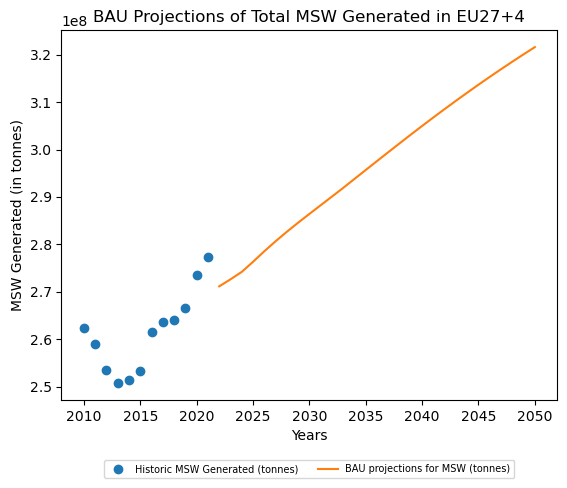

In [35]:
# Plots for EU 27+4
x = np.arange(2010,2022)
y = df_filtered["MSW_GEN_T"].loc[df_filtered["TIME"].isin(x)]
fig = plt.plot(x,y,'o', label='Historic MSW Generated (tonnes)')

#plotting BAU projections of adjusted formula
x = np.arange(2022,2051)
y = df_filtered["MSW_GEN_T"].loc[df_filtered["TIME"].isin(x)]
plt.plot(x,y,'-', label = 'BAU projections for MSW (tonnes)')

plt.xlabel('Years')
plt.ylabel('MSW Generated (in tonnes)')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, prop={'size': 7})
plt.title('BAU Projections of Total MSW Generated in EU27+4')
plt.show()

/var/folders/bm/tmx1rxns5yvdzj8zkylvh57xfl_lm7/T/ipykernel_97904/2629141152.py:13: OptimizeWarning: Unknown solver options: maxfev
  results = minimize(objective, initial_params, args=(years, eu_data["INC%"].to_numpy(),eu_data["DIS%"].to_numpy(),eu_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, options ={ 'maxfev': 10000})


Text(0.5, 1.0, 'Trend Analysis of Treatment Methods')

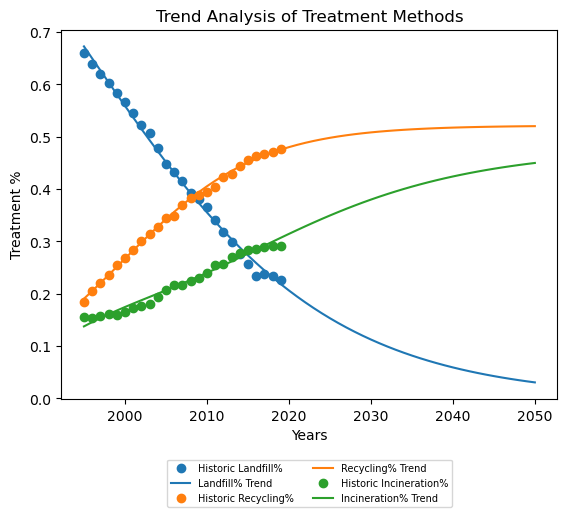

In [36]:
#Incineration %

eu_data = eu_msw.loc[eu_msw['Country']=="EU27+4"]
years = np.arange(eu_data.iloc[0]["TIME_PERIOD"], 2051)

initial_params = [eu_data.iloc[0]["DIS%"], -1, eu_data.iloc[0]["TIME_PERIOD"], eu_data.iloc[0]["RCY%"], 1, eu_data.iloc[0]["TIME_PERIOD"]]
bounds = [(-np.inf, np.inf), (-np.inf, 0), (-np.inf, np.inf),(-np.inf, 1),(0, np.inf),(-np.inf, np.inf)]

cons = [{'type': 'ineq', 'fun': partial(con_4, years=years)}
        ]

years = eu_data["TIME_PERIOD"].to_numpy()
results = minimize(objective, initial_params, args=(years, eu_data["INC%"].to_numpy(),eu_data["DIS%"].to_numpy(),eu_data["RCY%"].to_numpy()), bounds = bounds, constraints=cons, options ={ 'maxfev': 10000})

# Extract the fitted parameters
params = results.x
params_D = params[0:3]
params_R = params[3:]

#Landfill%
L_fit, k_fit, x0_fit = params_D

#plotting time series of Landfill %
x = eu_data["TIME_PERIOD"]
y = eu_data["DIS%"]
fig = plt.plot(x,y,'o', label='Historic Landfill%', color = '#1f77b4')
x = np.arange(eu_data.iloc[0]["TIME_PERIOD"],2051)
plt.plot(x, logistic_fun(x, L_fit, k_fit, x0_fit),'-',label = 'Landfill% Trend', color = '#1f77b4')


#Recycling %
# Extract the fitted parameters
L_fit, k_fit, x0_fit = params_R
#plotting time series of recycling %
x = eu_data["TIME_PERIOD"]
y = eu_data["RCY%"]
plt.plot(x,y,'o', label = 'Historic Recycling%', color='#ff7f0e')
x = np.arange(reg_data.iloc[0]["TIME_PERIOD"],2051)
plt.plot(x, logistic_fun(x, L_fit, k_fit, x0_fit),'-',label = 'Recycling% Trend',  color='#ff7f0e')

#plotting time series of incineration %
x = eu_data["TIME_PERIOD"]
y = eu_data["INC%"]
plt.plot(x,y, 'o', label = 'Historic Incineration%', color = '#2ca02c')

x = np.arange(reg_data.iloc[0]["TIME_PERIOD"],2051)
plt.plot(x, I(params, x),'-',label = 'Incineration% Trend', color = '#2ca02c')
plt.xlabel('Years')
plt.ylabel('Treatment %')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, prop={'size': 7})
plt.title('Trend Analysis of Treatment Methods')

## BAU Projections for Ash quantities

Now the two models are combined to get the ash quantities for the future.

In [37]:
ash_data = pd.concat([bau_data[df_filtered.columns],df_filtered],ignore_index = True)

In [38]:
ash_data["SLASH_bottomAshesWasteInc"] = ash_data['INC_T']*0.28
ash_data["SLASH_flyAshesWasteInc"] = ash_data['INC_T']*0.03
#eu_msw_his["SLASH_boilerAshesWasteInc"] = eu_msw_his['MSW_WasteInc']*0.03
ash_data.drop(['MSW_GEN_T','INC_T'], axis = 'columns', inplace = True)
ash_data.rename(columns= {'TIME':'Year','LOCATION':'Country'},inplace=  True)


### Reformatting into the output structure

In [39]:
columns = ['Waste Stream', 'Country', 'Year', 'Scenario', 'Substance main parent',
           'Stock/Flow ID', 'Value', 'Unit', 'Data Quality', 'Reference', 'Remark 1',
           'Remark 2', 'Remark 3']


ash_data= pd.melt(ash_data, id_vars=['Country','Year'], value_vars = ['SLASH_bottomAshesWasteInc',
                                'SLASH_flyAshesWasteInc'],var_name='Stock/Flow ID', value_name='Value')

#Changing all values to tonnes

ash_data['Unit'] = 't'

#adding  waste stream
ash_data['Waste Stream'] = 'SLASH'

#adding LowKey codes
subs_main_parent = {'SLASH_flyAshesWasteInc':'19 01 13*','SLASH_bottomAshesWasteInc':'19 01 11*',
                    'SLASH_boilerAshesWasteInc':'19 01 15*'}
ash_data['Substance main parent'] = ash_data['Stock/Flow ID'].map(subs_main_parent)

#Rearrange columns

ash_data['Scenario'] = np.where(ash_data['Year'] <= 2021, 'OBS', 'BAU')
ash_data[['Reference']] = np.nan
ash_data[['Remark 2']] = np.nan

ash_data.loc[(ash_data["Country"]=='GBR')&(ash_data['Year']<=2021),['Remark 1']] = 'Estimated from OECD MSW incineration quantities'
conditions = (((ash_data["Country"]=='DNK')&(ash_data["Year"]==2010)) | ((ash_data["Country"]=='IRL')&(ash_data["Year"]==2013)) | ((ash_data["Country"]=='IRL')&(ash_data["Year"]==2015)) | ((ash_data["Country"]=='ISL')&(ash_data["Year"]==2019)))
ash_data.loc[conditions,['Remark 1']]='Missing data, estimated from Eurostat MSW incineration quantities of neighbouring years '
ash_data.loc[(ash_data["Country"]!='GBR') & (ash_data['Year']<=2021) & ~conditions,['Remark 1']]='Estimated from Eurostat MSW incineration quantities'

#remarlk for bau scenario
conditions = (((ash_data["Country"]=='IRL')&(ash_data["Year"]==2021)) | ((ash_data["Country"]=='GRC')&(ash_data["Year"]==2020))| ((ash_data["Country"]=='GRC')&(ash_data["Year"]==2021)))
ash_data.loc[(ash_data['Scenario']=='BAU') | conditions,['Remark 1']] = 'Estimated from models - Check Reference'

ash_data[['Remark 3']] = 'Sowmya Ravisandiran'


ash_data.loc[ash_data['Year'] <= 2021,['Data Quality']] = 2
ash_data.loc[ash_data['Year'] > 2035,['Data Quality']] = 4
ash_data.loc[(ash_data['Year'] > 2021)&(ash_data['Year']<=2035),['Data Quality']] = 3

ash_data = ash_data[columns]

#eu_msw_his.drop(eu_msw_his.loc[eu_msw_his["Country"]=='EU27_2020'].index, inplace = True)


#ash_data.to_csv('Data_Structure_Task4.1_Task4.2_BAU.csv', index = False)
